Ethan Ho
017157582
CMPE 188

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score,roc_curve, roc_auc_score
from sklearn.svm import LinearSVC, SVC
import seaborn as sns

In [160]:
dataset = pd.read_csv("E:/vs/school/CMPE_188/data/wine.csv")
columns = ["Score", "Alcohol", "Malic Acid", "Ash", "Alcalinity of Ash", "Magnesium", "Total Phenols", "Flavanoids", "Nonflavanoid Phenols", "Proanthocyanins", "Color Intensity", "Hue", "OD280/OD315", "Proline"]
dataset.columns = columns
dataset.head(10)

,Score,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315,Proline
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
5,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
6,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
7,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
8,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045
9,1,14.10,2.16,2.30,18.0,105,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510


The dataset came with no columns at it only has 14 of the original 30 features of the dataset. I went ahead and included the feature names I saw atributed by Riccardo Leardi however I am unsure if the order of the columns matches up with the data below it.

array([[<Axes: title={'center': 'Score'}>,
        <Axes: title={'center': 'Alcohol'}>,
        <Axes: title={'center': 'Malic Acid'}>,
        <Axes: title={'center': 'Ash'}>],
       [<Axes: title={'center': 'Alcalinity of Ash'}>,
        <Axes: title={'center': 'Magnesium'}>,
        <Axes: title={'center': 'Total Phenols'}>,
        <Axes: title={'center': 'Flavanoids'}>],
       [<Axes: title={'center': 'Nonflavanoid Phenols'}>,
        <Axes: title={'center': 'Proanthocyanins'}>,
        <Axes: title={'center': 'Color Intensity'}>,
        <Axes: title={'center': 'Hue'}>],
       [<Axes: title={'center': 'OD280/OD315'}>,
        <Axes: title={'center': 'Proline'}>, <Axes: >, <Axes: >]],
      dtype=object)

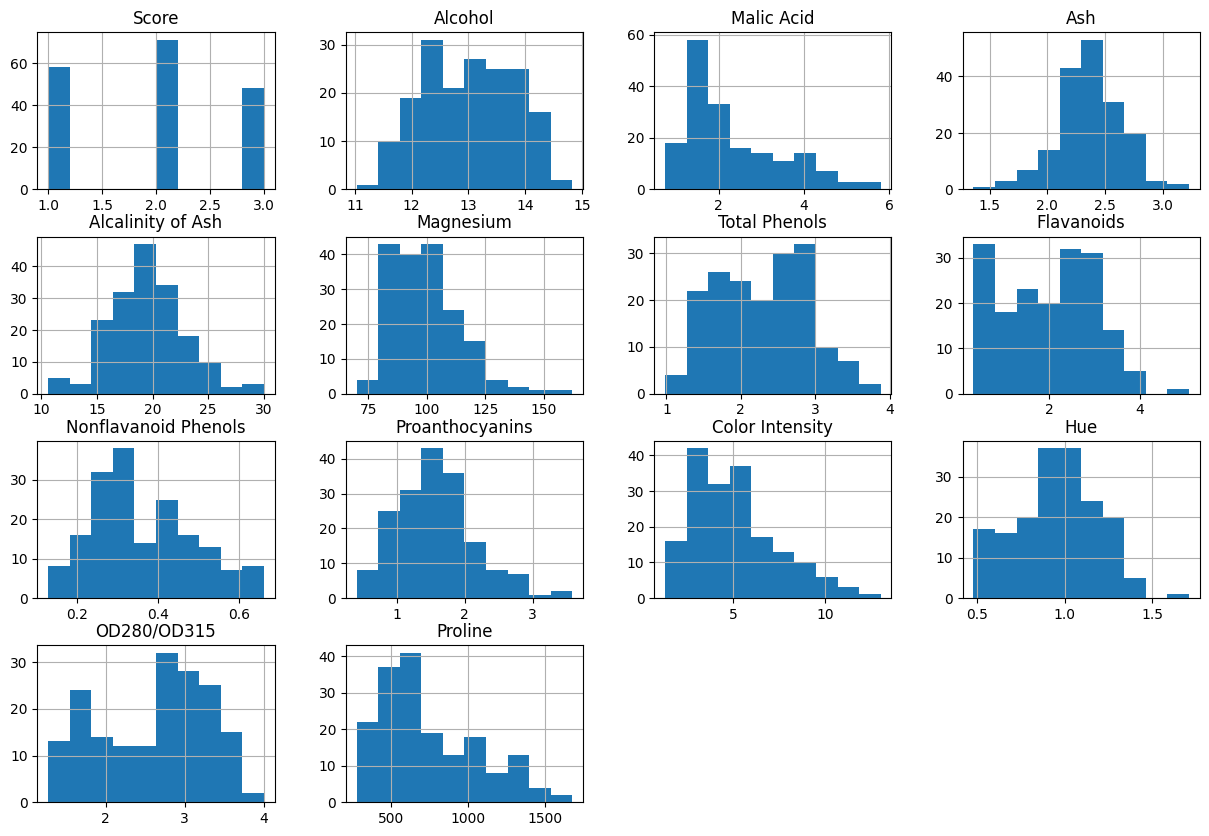

In [161]:
dataset.hist(figsize=(15, 10), layout=(4, 4))

It seems like most of the features are of guassian distribution like `Ash`, `Alcalinity of Ash`, and `Alcohol`. It was advised to standardized some of the features within the dataset and after doing a bit of research it seems like that was the move especially since we will be using SVMs. I havent decided on which columns yet but it may be all of them since we are it is required for SVMs.

In [162]:
dataset.describe()


,Score,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315,Proline
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,1.943503,12.993672,2.339887,2.366158,19.516949,99.587571,2.292260,2.023446,0.362316,1.586949,5.054802,0.956983,2.604294,745.096045
std,0.773991,0.808808,1.119314,0.275080,3.336071,14.174018,0.626465,0.998658,0.124653,0.571545,2.324446,0.229135,0.705103,314.884046
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.360000,1.600000,2.210000,17.200000,88.000000,1.740000,1.200000,0.270000,1.250000,3.210000,0.780000,1.930000,500.000000
50%,2.000000,13.050000,1.870000,2.360000,19.500000,98.000000,2.350000,2.130000,0.340000,1.550000,4.680000,0.960000,2.780000,672.000000
75%,3.000000,13.670000,3.100000,2.560000,21.500000,107.000000,2.800000,2.860000,0.440000,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [163]:
dataset.isnull().sum()

Score                   0
Alcohol                 0
Malic Acid              0
Ash                     0
Alcalinity of Ash       0
Magnesium               0
Total Phenols           0
Flavanoids              0
Nonflavanoid Phenols    0
Proanthocyanins         0
Color Intensity         0
Hue                     0
OD280/OD315             0
Proline                 0
dtype: int64

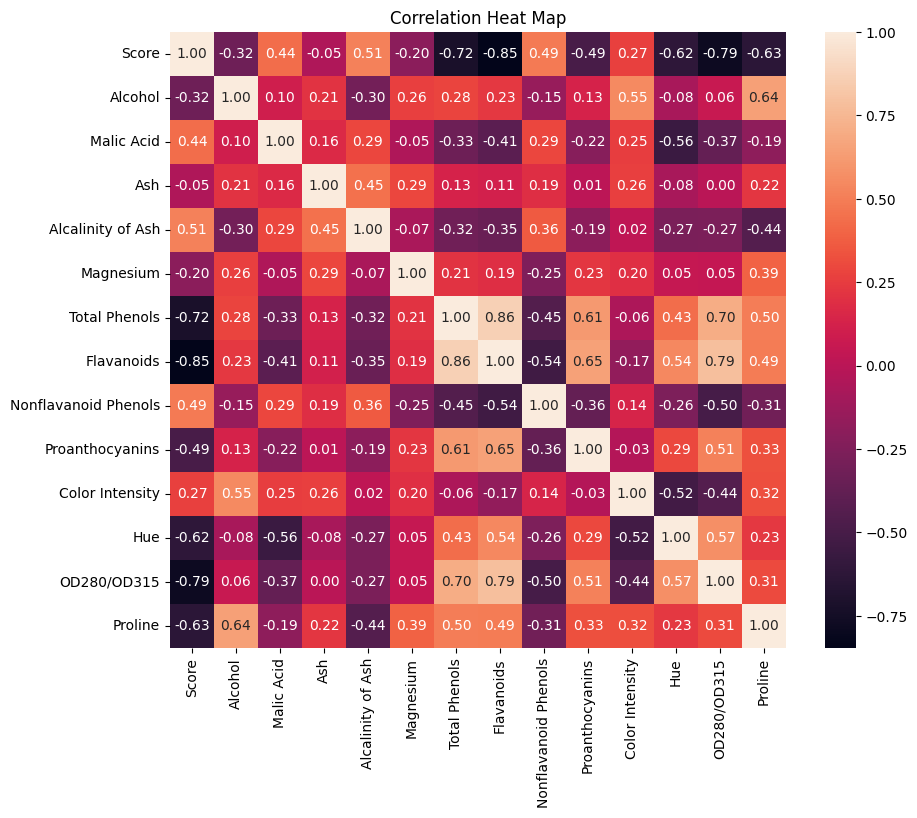

In [164]:
plt.figure(figsize=(10,8))
corr_map = dataset.corr("pearson")
sns.heatmap(corr_map, square=True, annot=True, fmt='.2f')
plt.title("Correlation Heat Map")
plt.show()

We can see that many of the coloums do have strong correlation with each other especially `Total Phenols`, `Flavanoids`, and `OD280/OD315` as they are negativly correlated to the score of the wine. I don't see the other columns having strong correlation with each other so we dont have to worry about removing a column for repetative data.

In [165]:
# Data Split
x = dataset.drop(["Score"], axis=1)
y = pd.DataFrame(dataset["Score"])

# Standardize
scaler = StandardScaler().fit(x)
X = pd.DataFrame(scaler.transform(x))


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(x_train.head())
print(y_train.head())

           0         1         2         3         4         5         6   \
156 -0.674096  0.618299  0.998321  2.249436 -0.183075 -0.627924 -1.449487   
136 -0.574905  2.840226  0.998321  1.648228 -0.253827 -0.804011 -1.429403   
98  -0.872479  0.743730 -0.569292 -0.456001 -0.819841  0.892823  0.970599   
158  0.602995 -0.600178  0.998321  0.896718 -0.749089  0.492626 -0.927311   
38   1.520517  1.478400  0.524392 -1.898901  2.010230  1.132941  1.020808   

           7         8         9         10        11        12  
156  2.153523 -0.784221  1.054933 -1.256016 -1.243470  0.429640  
136  2.153523 -0.854405 -0.023643 -0.599523 -1.300360 -0.732806  
98   0.705418  2.145975 -1.188505  2.026449  0.321012 -1.079947  
158  1.268570  1.233579  2.888512 -1.693678 -1.172357 -0.398404  
38  -1.305841  0.865111  0.019500 -0.293159  1.316591  0.047466  
     Score
156      3
136      3
98       2
158      3
38       1


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: title={'center': '5'}>,
        <Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>],
       [<Axes: title={'center': '8'}>, <Axes: title={'center': '9'}>,
        <Axes: title={'center': '10'}>, <Axes: title={'center': '11'}>],
       [<Axes: title={'center': '12'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

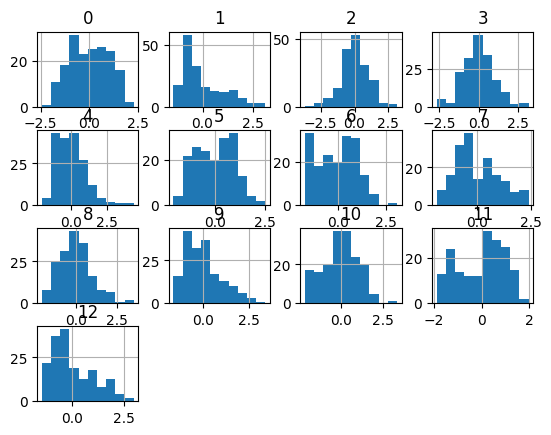

In [166]:
X.hist()

In [167]:
models = []

models.append((
    "Linear SVC",
    LinearSVC(C=1, loss="hinge", random_state=1, max_iter=1000000)
))
models.append((
    "Kernel SVC",
    SVC(kernel="rbf", degree=2, C=1, random_state=1, max_iter=1000000)
))
models.append((
    "Poly SVC",
    SVC(kernel="poly", degree=2, C=1, random_state=1, max_iter=1000000)
))
models.append((
    "Random Forrest",
    RandomForestClassifier(max_depth=2, random_state=42)
))
models.append((
    "Adaboosting",
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=200, algorithm="SAMME", learning_rate=0.5, random_state=42)
))

results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_result = cross_val_score(model, x_test, y_test, cv=kfold, scoring="accuracy")
    results.append(cv_result)
    names.append(name)

    

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was e

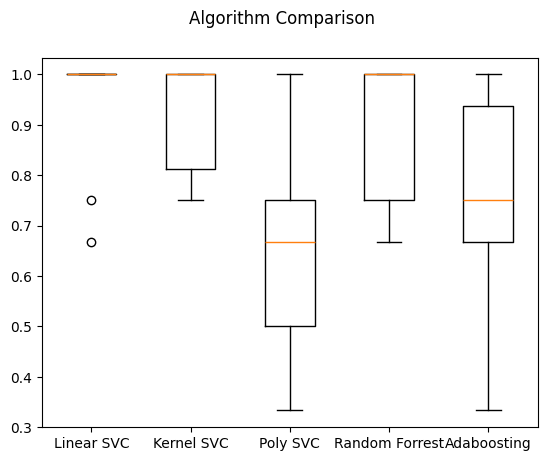

In [168]:
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

When comparing the models we can see that the Polynomial Kernal significantly underperforms the rest of the models with large variance and a low mean of around 0.77. While tuning the degree hyper parameter I noticed that the performance dropped as I increased the degree. Adaboosting does underperform as well as I tuned the learning hyper parameter but there was no significant changes. The Linear SVC, Kernel SVC, and Random Forrest performed really well with occasional outliars which reappear whenever I refresh a new train/test split. However this performance is expected given that the dataset was noted to be tailerd for this kind of classification.

In [169]:
rbf_svc = SVC(kernel='rbf', C=1.0, degree=2, random_state=42, max_iter=1000000, probability=True)
rbf_svc.fit(x_train, y_train)

y_bin = label_binarize(y, classes=np.unique(y))
n_classes = y_bin.shape[1]

x_train, x_test, y_train, y_test = train_test_split(x, y_bin, test_size=0.3, random_state=42)
y_score = rbf_svc.predict_proba(x_test)

auc_scores = roc_auc_score(y_test, y_score, average=None, multi_class='ovr')

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


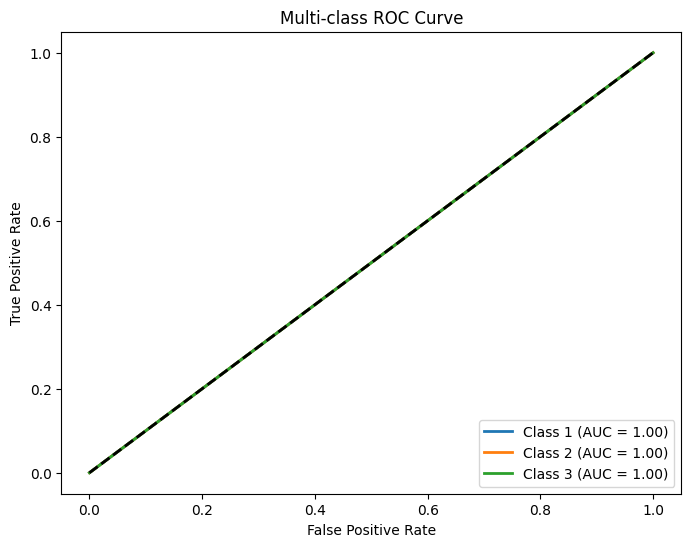

In [171]:
fpr = {}
tpr = {}
roc_auc = {}
classes = np.unique(y)

for i in range(n_classes):
    fpr[i], tpr[i], threshold = roc_curve(y_test[:, i], y_score[:, 1])
    roc_auc[i] = roc_auc_score(fpr[i], tpr[i])
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()

For some odd reason it seems like the curves are on the line when they have 100% accuracy which is incorrect. They just be at the top and the area udner the curve should cover the entire graph if it really is accurate. However we do know that our RBF Kernel SVC was able to classify each class of wine correctly most of the time just like the other classifiers so this is something we expected. The roc curve alongside plotting the RBF Kernel SVC with the other models tells me that this is the best performing model for this dataset.